<a href="https://colab.research.google.com/github/emilyteixeira/emilys-cv-journey/blob/main/vis101_t2_manipulacao_e_cores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Pós-Graduação em Visão Computacional</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>VIS101: Fundamentos da Visão Computacional</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

Dando sequência ao primeiro contato. Já vimos que a imagem é uma matriz. Agora
manipulamos os pixels, recortamos regiões e exploramos as cores nos espaços RGB e HSV.

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (6, 4), 'font.size': 12})
print('Setup pronto.')

Setup pronto.


In [ ]:
img = cv2.imread("data/apple.jpg")
print("forma:", img.shape)

forma: (853, 1280, 3)


## Acessando e modificando pixels

Cada pixel é um vetor de três valores na ordem **B, G, R**. Podemos ler o valor de um
pixel e também escrever sobre uma região, sempre trabalhando em uma cópia.

In [ ]:
print("pixel (100, 200):", img[100, 200])

pixel (100, 200): [ 51 141 106]


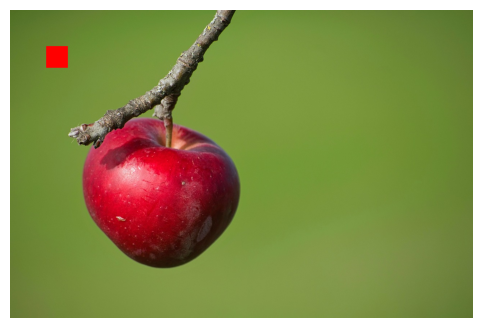

In [ ]:
img_mod = img.copy()
img_mod[100:160, 100:160] = (0, 0, 255)   # bloco vermelho (B, G, R)

plt.imshow(img_mod[:, :, ::-1])
plt.axis("off")
plt.show()

## Região de interesse

Recortar uma região é fatiar a matriz, escolhendo um intervalo de linhas e de colunas.

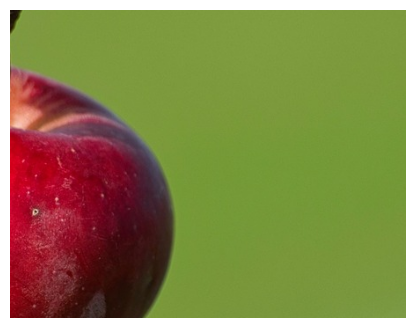

In [ ]:
roi = img[250:600, 450:900]

plt.imshow(roi[:, :, ::-1])
plt.axis("off")
plt.show()

## Os canais de cor (RGB)

Cada canal é, isoladamente, uma matriz de intensidades. No canal vermelho, a maçã
aparece clara, porque tem intensidade alta nessa cor.

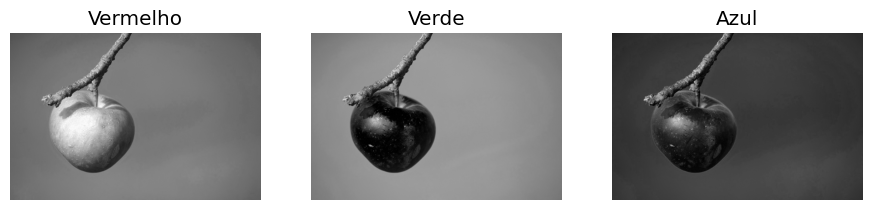

In [ ]:
B, G, R = cv2.split(img)

fig, ax = plt.subplots(1, 3, figsize=(11, 3))
for a, canal, nome in zip(ax, [R, G, B], ["Vermelho", "Verde", "Azul"]):
    a.imshow(canal, cmap="gray")
    a.set_title(nome)
    a.axis("off")
plt.show()

## O espaço de cor HSV

O HSV separa o **matiz** (a cor em si) da saturação e do brilho. Isso facilita selecionar
objetos por cor, algo difícil no RGB, em que a cor fica espalhada pelos três canais.

In [ ]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
print("forma HSV:", hsv.shape)

forma HSV: (853, 1280, 3)


## Segmentação por cor

Vamos isolar a maçã criando uma **máscara** dos pixels vermelhos. O vermelho ocupa as
duas pontas da faixa de matiz, então combinamos dois intervalos.

In [ ]:
faixa_baixa = cv2.inRange(hsv, (0, 100, 60), (10, 255, 255))
faixa_alta  = cv2.inRange(hsv, (170, 100, 60), (179, 255, 255))
mask = faixa_baixa | faixa_alta

print("pixels selecionados:", int((mask > 0).sum()))

pixels selecionados: 108713


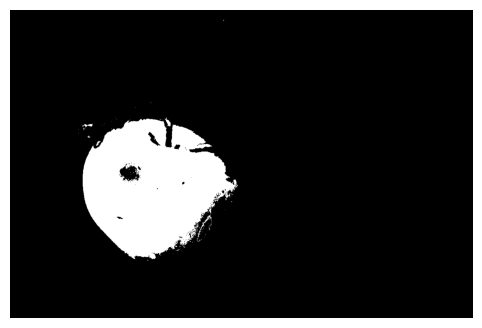

In [ ]:
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

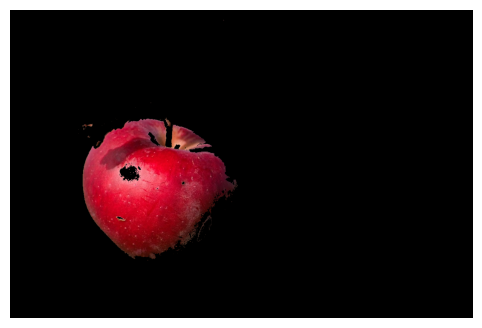

In [ ]:
resultado = cv2.bitwise_and(img, img, mask=mask)

plt.imshow(resultado[:, :, ::-1])
plt.axis("off")
plt.show()

## Síntese

Pixels são lidos e escritos por indexação, regiões por fatiamento. No RGB, a cor se
distribui pelos três canais. No HSV, o matiz isola a cor, o que torna a segmentação por
cor direta com uma máscara.